In [3]:
import numpy as np

# from optimal_traj_control.automated_test.optimal_control import (
#     dynamic_unicycle_optimal_traj_derivations,
#     convert_sym_prob_to_cvxpy_prob,
# )
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

import matplotlib.pyplot as plt
# %matplotlib notebook

import cvxpy as cp

In [2]:
(sympy_f, sympy_gs, sympy_opt_vars) = dynamic_unicycle_optimal_traj_derivations()
sympy_f

delta**2*p + 0.5*f**2 + 0.5*tau**2

In [3]:

(cntrl_prob_cvxpy, prob_var_map, prob_param_map) = convert_sym_prob_to_cvxpy_prob(
    sympy_f, sympy_gs, sympy_opt_vars
)

(prob_var_map, prob_param_map)

([(f, Variable((), f)),
  (tau, Variable((), \tau)),
  (delta, Variable((), \delta))],
 [(p, Parameter((), nonneg=True)),
  (\alpha, Parameter(())),
  (x_tr(t), Parameter(())),
  (x, Parameter(())),
  (cos(\theta), Parameter(())),
  (y_tr(t), Parameter(())),
  (y, Parameter(())),
  (sin(\theta), Parameter(())),
  (\beta, Parameter(())),
  (\omega, Parameter(())),
  (v, Parameter(())),
  (Derivative(x_tr(t), t), Parameter(())),
  (Derivative(y_tr(t), t), Parameter(())),
  (\theta_tr(t), Parameter(())),
  (\theta, Parameter(())),
  (Derivative(\theta_tr(t), t), Parameter(()))])

In [4]:
def get_param_var(mapping, idxs):
    params = []
    for idx in idxs:
        pair = mapping[idx]

        print(f"\tSympy: {pair[0]}")
        params.append(pair[1])
    return tuple(params)


# restores handles to optimization variables (cvxpy)
print("Variables:")
(u_f_var, u_t_var, delta_var) = get_param_var(prob_var_map, (0, 1, 2))


# restores handles to parameters (cvxpy)
print("Parameters:")
p_par = get_param_var(prob_param_map, (0,))[0]
(alpha_par, beta_par) = get_param_var(
    prob_param_map, (1, 8)
)
(x_par, y_par, theta_par, v_par, omega_par) = get_param_var(
    prob_param_map, (3, 6, 14, 10, 9)
)

(x_traj_par, y_traj_par, theta_traj_par) = get_param_var(
    prob_param_map, (2, 5, 13, )
)
(
    dot_x_traj_par,
    dot_y_traj_par,
    dot_theta_traj_par,
) = get_param_var(prob_param_map, (11, 12, 15))

# as cvxpy is a convex optimization library we must use these auxiliarly
# variables as replacement for sin(theta) and cos(theta)
# NOTE: given theta is a parameter set at each controller update step we can do
# this without loss of convexity with respect to optimization variables u_f, u_t
(sin_theta_aux_par, cos_theta_aux_par) = get_param_var(prob_param_map, (7, 4))

Variables:
	Sympy: f
	Sympy: tau
	Sympy: delta
Parameters:
	Sympy: p
	Sympy: \alpha
	Sympy: \beta
	Sympy: x
	Sympy: y
	Sympy: \theta
	Sympy: v
	Sympy: \omega
	Sympy: x_tr(t)
	Sympy: y_tr(t)
	Sympy: \theta_tr(t)
	Sympy: Derivative(x_tr(t), t)
	Sympy: Derivative(y_tr(t), t)
	Sympy: Derivative(\theta_tr(t), t)
	Sympy: sin(\theta)
	Sympy: cos(\theta)


In [5]:
# set the relative importance for each error

alpha_par.value = 1.0  # distance loss
beta_par.value = 1.0  # angle loss

p_par.value = 0.2

# gamma_par.value = 1e-3  # IGNORE: velocity loss
# delta_par.value = 1e-3  # IGNORE: angular velocity loss

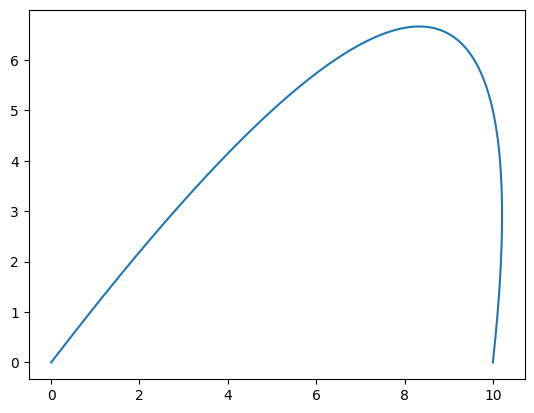

In [ ]:
# defines a notional trajectory

t_f = 20.0
dt = 0.01
spline_method = CubicSpline  # for convenience


t = np.linspace(0, 20.0, int(t_f / dt))
points = np.array(
    # defines a smoothed triangular path
    [
        # (x, y, t)
        (0.0, 0.0, 0.0),
        (5.0, 5.0, 10.0),
        (10.0, 0.0, 20.0),
    ]
)

(x_spline, y_spline) = (
    spline_method(points[:, 2], points[:, 0]),
    spline_method(points[:, 2], points[:, 1]),
)
(traj_x, traj_y, dot_traj_x, dot_traj_y) = (
    x_spline(t),
    y_spline(t),
    x_spline.derivative()(t),
    y_spline.derivative()(t),
)

(traj_theta, dot_traj_theta) = (
    np.atan2(traj_y, traj_x),
    np.atan2(dot_traj_y, dot_traj_x),
)

fig, ax = plt.subplots()
ax.plot(traj_x, traj_y)

plt.show()

[0.2, 1.0, np.float64(5.007503751875938), np.float64(0.0), np.float64(-0.7120404940423706), np.float64(4.999988738741557), np.float64(0.0), np.float64(0.7021384014878383), 1.0, np.float64(-1.839747325999315e+18), np.float64(0.0), np.float64(0.5), np.float64(-0.0015007503751876428), np.float64(0.7846472248652603), np.float64(-4.958119046373292e+18), np.float64(-0.0030014917369104955)]
False
Traj x: 0.0, traj y: [0.         0.01       0.01998998 ... 0.01998998 0.01       0.        ]
[0.2, 1.0, np.float64(0.0), np.float64(0.0), np.float64(-0.7120404940423706), np.float64(0.0), np.float64(0.0), np.float64(0.7021384014878383), 1.0, np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(0.0), np.float64(1.5707963267948966), np.float64(1.1071487177940904)]
Polishing not needed - no active set detected at optimal point
True
u_f: 0.0, u_t: -3.0210321078562073e-10, delta: 4.808108417027659e-10
[[ 0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00]
 [ 1.5707

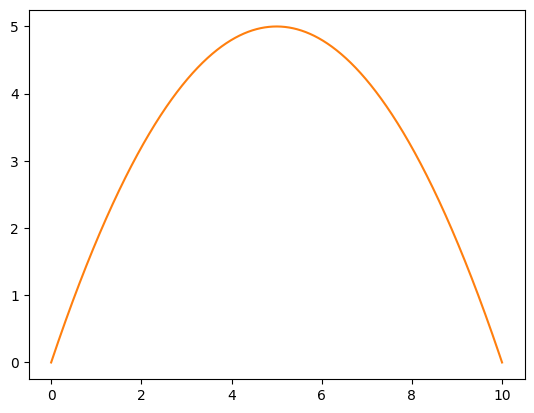

array([ 0.00000000e+00,  0.00000000e+00, -4.97653359e+18,  0.00000000e+00,
       -1.84316059e+18])

In [14]:
p0 = np.array([0.0, 0.0, np.pi / 2, 0.0, 0.0])  # pointing upwards
u0 = np.array([0.0, 0.0])


print([param.value for param in cntrl_prob_cvxpy.parameters()])
print(cntrl_prob_cvxpy.parameters()[0] is alpha_par)


def dyn_unicycle_f(t, p, u):
    x, y, theta, v, omega = p
    u_f, u_t = u

    dot_state = np.array([v * np.cos(theta), v * np.sin(theta), omega, u_f, u_t])
    return dot_state


p_hist = []
u_hist = []

p = p0
u = u0

for i in range(len(t)):
    # generate controller input form the optimal controller

    p_hist.append(p)
    u_hist.append(u)

    # gets the current state
    x_curr, y_curr, theta_curr, v_curr, omega_curr = p

    # gets the current trajectory state
    traj_x_curr, traj_y_curr, traj_theta_curr = (traj_x[i], traj_y[i], traj_theta[i])
    print(f"Traj x: {traj_x_curr}, traj y: {traj_y}")
    dot_traj_x_curr, dot_traj_y_curr, dot_traj_theta_curr = (
        dot_traj_x[i],
        dot_traj_y[i],
        dot_traj_theta[i],
    )

    # set parameters of the optimization problem

    x_par.value = x_curr
    y_par.value = y_curr
    theta_par.value = theta_curr
    v_par.value = v_curr
    omega_par.value = omega_curr

    x_traj_par.value = traj_x_curr
    y_traj_par.value = traj_y_curr
    theta_traj_par.value = traj_theta_curr
    # v_traj_par.value = 0.0  # not generated and error gain disabled
    # omega_traj_par.value = 0.0  # not generated and error gain disabled

    dot_x_traj_par.value = dot_traj_x_curr
    dot_y_traj_par.value = dot_traj_y_curr
    dot_theta_traj_par.value = dot_traj_theta_curr
    # dot_v_traj_par.value = 0.0  # not generated and error gain disabled
    # dot_omega_traj_par.value = 0.0  # not generated and error gain disabled

    print([param.value for param in cntrl_prob_cvxpy.parameters()])

    # set the auxiliary variables
    sin_theta_aux_par.value = np.sin(theta_curr)
    cos_theta_aux_par.value = np.cos(theta_curr)

    # run optimization

    cntrl_prob_cvxpy.solve(warm_start=True)
    print(cntrl_prob_cvxpy.constraints[0].value())

    u_f_optim = u_f_var.value
    u_t_optim = u_t_var.value
    delta_optim = delta_var.value

    print(f"u_f: {u_f_optim}, u_t: {u_t_optim}, delta: {delta_optim}")

    u = np.array([u_f_optim, u_t_optim])

    # update history

    # run dynamics (zero order hold on dynamics for dt)
    result = solve_ivp(lambda t, y: dyn_unicycle_f(t, y, u=u), [0, dt], p)
    print(result.y)

    p = result.y[:, -1]
    # x_curr, y_curr, theta_curr, v_curr, omega_curr = p

    if i > 1000:
        break

p_hist = np.array(p_hist)
u_hist = np.array(u_hist)

fig, ax = plt.subplots()

ax.plot(p_hist[:, 0], p_hist[:, 1])
ax.plot(traj_x, traj_y)

plt.show()

p

In [15]:
cntrl_prob_cvxpy.get_problem_data(cp.OSQP)[0]

/home/samuel/Documents/School/UWaterloo_MASc/Research_Activities/research-geo-diff-opt-layer/.venv/lib/python3.12/site-packages/cvxpy/reductions/solvers/solving_chain.py:242: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  warnings.warn(DPP_ERROR_MSG)


{'dims': (zero: 0, nonpos: 1, exp: 0, soc: [], psd: []),
 'param_prob': <cvxpy.reductions.qp2quad_form.qp_matrix_stuffing.ParamQuadProg at 0x7a8fffbcf8f0>,
 'P': <Compressed Sparse Column sparse array of dtype 'float64'
 	with 3 stored elements and shape (3, 3)>,
 'q': array([0., 0., 0.]),
 'A': <Compressed Sparse Column sparse array of dtype 'float64'
 	with 0 stored elements and shape (0, 3)>,
 'b': array([], dtype=float64),
 'F': <Compressed Sparse Column sparse array of dtype 'float64'
 	with 3 stored elements and shape (1, 3)>,
 'G': array([-3.38467022e+36]),
 'bool_vars_idx': [],
 'int_vars_idx': [],
 'lower_bounds': None,
 'upper_bounds': None,
 'n_var': 3,
 'n_eq': 0,
 'n_ineq': 1}